# Explore Solo Floats

In [27]:
# imports
from importlib import reload
import os
import glob

import numpy as np

from scipy.io import loadmat

from matplotlib import pyplot as plt

from profiler import floatdata
#from cugn import gliderpairs
from profiler import utils as cugn_utils
from profiler import binning

import pymatreader

# Load

In [2]:
datafile = '/home/xavier/Projects/Oceanography/data/ARCTERX/Floats/8996.mat'
d8996 = pymatreader.read_mat(datafile)
d8996['bindata'].keys()

dict_keys(['time', 'lat', 'lon', 'u', 'v', 'tsurf', 'lonsurf', 'latsurf', 'usurf', 'vsurf', 'sn', 'depth', 't', 's', 'theta', 'sigma', 'rho', 'p', 'bintime', 'tbincombine', 'sbincombine', 'nsq', 'mld', 'x', 'dn', 'gatz', 'gbsz', 'tu', 'function', 'readme'])

# Explore

In [3]:
d8996['bindata']['depth']

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200], dtype=uint8)

# Now in code

In [4]:
reload(floatdata)
s8996 = floatdata.load_dataset('ARCTERX-Leg2')

----

# Binning

## Load the full file

In [7]:
ffile = '/run/user/1000/gvfs/smb-share:server=10.43.20.20,share=cruiseshare/Data/floats/solo/data/8999.mat'
f = pymatreader.read_mat(ffile)

In [8]:
f['data'].keys()

dict_keys(['time', 'lat', 'lon', 'p', 't', 's', 'theta', 'sigma', 'rho', 'depth', 'praw', 'traw', 'sraw', 'thetaraw', 'sigmaraw', 'rhoraw', 'depthraw', 'eng', 'qual', 'orig', 'u', 'v', 'usurf', 'vsurf', 'tsurf', 'lonsurf', 'latsurf', 'sn', 'depthmax'])

## Bin me

In [10]:
reload(binning)
bindata = binning.run(f['data'])

In [12]:
bindata.keys()

dict_keys(['time', 'lat', 'lon', 'u', 'v', 'tsurf', 'usurf', 'vsurf', 'depth', 't', 's', 'theta', 'sigma', 'rho', 'bintime'])

In [14]:
bindata['sigma'].shape

(20, 409)

# Check

In [25]:
bindata['sigma'][:,0]

array([23.13708346, 23.14681171, 23.14988275, 23.15245496, 23.15326659,
       23.15769788, 23.15898472, 23.16030297, 23.15999158, 23.15982968,
       23.17987872,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan])

In [26]:
bindata['time'][0]

np.float64(1738794720.0000029)

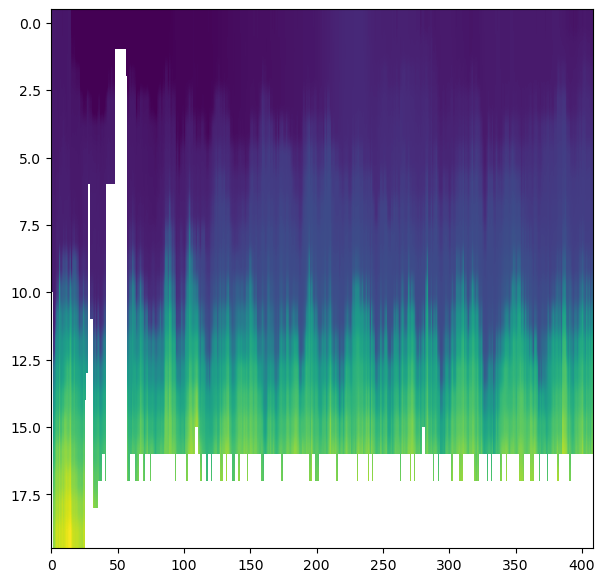

In [31]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
ax.imshow(bindata['sigma'], aspect='auto', vmin=23., vmax=25.)
#
plt.show()